Loaded images: 4032 x 3024
Good matches: 533
Inlier matches: 287
F:
 [[-1.51177062e-10 -5.06292656e-06  9.58827864e-03]
 [ 5.06223034e-06 -1.28706117e-08 -6.25732498e-02]
 [-9.65714143e-03  6.25400256e-02  1.00000000e+00]]


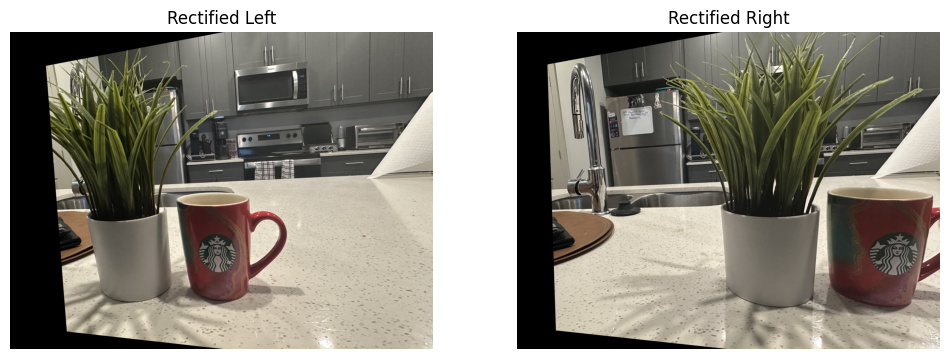

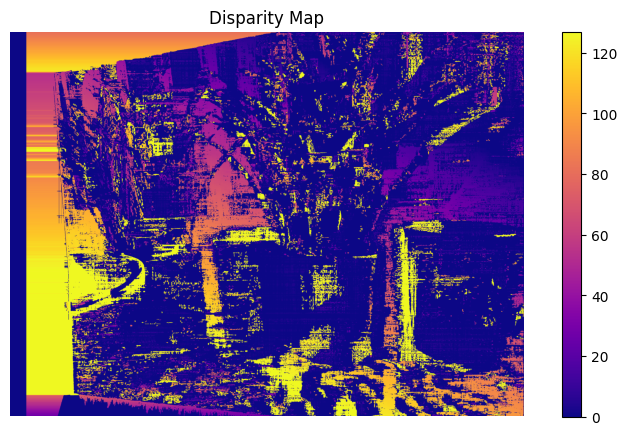

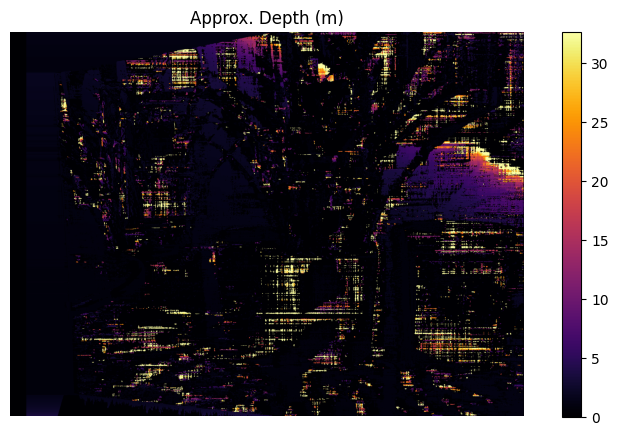

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt
%matplotlib inline

# === Load images ===
L, R = cv2.imread("stereo_left.jpg"), cv2.imread("stereo_right.jpg")
grayL, grayR = cv2.cvtColor(L, cv2.COLOR_BGR2GRAY), cv2.cvtColor(R, cv2.COLOR_BGR2GRAY)
h, w = grayL.shape
print("Loaded images:", w, "x", h)

# === Feature matching with SIFT + ratio test ===
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(grayL, None)
kp2, des2 = sift.detectAndCompute(grayR, None)
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)
good = [m for m, n in matches if m.distance < 0.7*n.distance]

pts1 = np.float32([kp1[m.queryIdx].pt for m in good])
pts2 = np.float32([kp2[m.trainIdx].pt for m in good])
print("Good matches:", len(good))

# === Fundamental matrix + inlier filtering ===
F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC, 1.0, 0.99)
pts1, pts2 = pts1[mask.ravel()==1], pts2[mask.ravel()==1]
print("Inlier matches:", len(pts1))
print("F:\n", F)

# === Rectification ===
retval, H1, H2 = cv2.stereoRectifyUncalibrated(pts1, pts2, F, (w,h))
if not retval:
    raise RuntimeError("Rectification failed. Check overlap and alignment.")
Lr, Rr = cv2.warpPerspective(L, H1, (w,h)), cv2.warpPerspective(R, H2, (w,h))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(Lr, cv2.COLOR_BGR2RGB)); plt.title("Rectified Left"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(Rr, cv2.COLOR_BGR2RGB)); plt.title("Rectified Right"); plt.axis('off')
plt.show()

# === StereoSGBM disparity ===
grayLr = cv2.cvtColor(Lr, cv2.COLOR_BGR2GRAY)
grayRr = cv2.cvtColor(Rr, cv2.COLOR_BGR2GRAY)

stereo = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=128,  # must be multiple of 16
    blockSize=7,
    P1=8*3*7**2,
    P2=32*3*7**2,
    disp12MaxDiff=1,
    uniquenessRatio=10,
    speckleWindowSize=50,
    speckleRange=32,
    mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY
)
disp = stereo.compute(grayLr, grayRr).astype(np.float32) / 16.0
disp[disp < 0] = 0

plt.figure(figsize=(10,5))
plt.imshow(disp, cmap='plasma')
plt.title("Disparity Map")
plt.axis('off')
plt.colorbar()
plt.show()

# === Approximate depth ===
B, fx = 0.08, 1200.0  # baseline (m), focal length (px) -- adjust B if needed
maskv = disp > 1
depth = np.zeros_like(disp)
depth[maskv] = (fx * B) / disp[maskv]

plt.figure(figsize=(10,5))
plt.imshow(np.clip(depth, 0, np.percentile(depth[maskv], 95)), cmap='inferno')
plt.title("Approx. Depth (m)")
plt.axis('off')
plt.colorbar()
plt.show()


Recovered pose:
R=
 [[ 9.99976067e-01 -1.85942721e-04 -6.91603683e-03]
 [ 2.69113382e-04  9.99927639e-01  1.20267832e-02]
 [ 6.91330008e-03 -1.20283565e-02  9.99903758e-01]] 
t=
 [[-0.06085492  0.00770661 -0.99811687]]


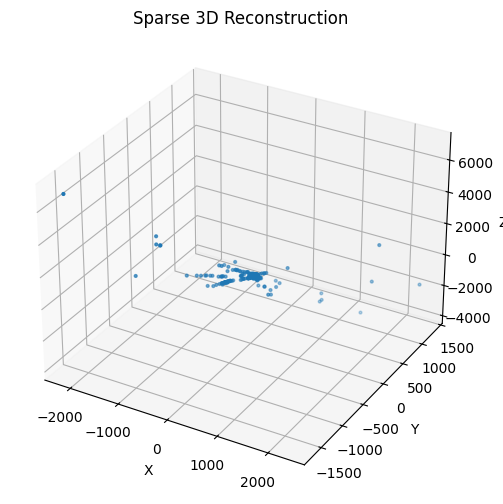

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

# === Reload images ===
L, R = cv2.imread("stereo_left.jpg"), cv2.imread("stereo_right.jpg")
grayL, grayR = cv2.cvtColor(L, cv2.COLOR_BGR2GRAY), cv2.cvtColor(R, cv2.COLOR_BGR2GRAY)
h, w = grayL.shape

# === Feature matches (SIFT) ===
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(grayL, None)
kp2, des2 = sift.detectAndCompute(grayR, None)
matches = cv2.BFMatcher().knnMatch(des1, des2, k=2)
good = [m for m,n in matches if m.distance < 0.7*n.distance]
pts1 = np.float32([kp1[m.queryIdx].pt for m in good])
pts2 = np.float32([kp2[m.trainIdx].pt for m in good])

# === Intrinsics (example, can replace with calibration) ===
fx = 1200.0
K = np.array([[fx,0,w/2],[0,fx,h/2],[0,0,1]])

# === Essential matrix + pose ===
E, maskE = cv2.findEssentialMat(pts1, pts2, K, cv2.RANSAC, 0.999, 1.0)
_, R, t, mask_pose = cv2.recoverPose(E, pts1, pts2, K)
print("Recovered pose:\nR=\n", R, "\nt=\n", t.T)

# === Triangulate points ===
P1 = K @ np.hstack((np.eye(3), np.zeros((3,1))))
P2 = K @ np.hstack((R, t))
pts4d = cv2.triangulatePoints(P1, P2, pts1.T, pts2.T)
pts3d = (pts4d[:3] / pts4d[3]).T

# === Plot sparse 3D points ===
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pts3d[:,0], pts3d[:,1], pts3d[:,2], s=4)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Sparse 3D Reconstruction')
plt.show()


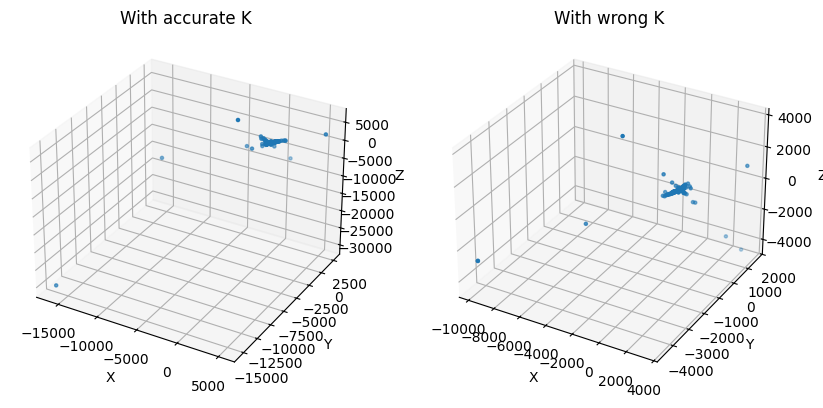

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

# === Example intrinsics ===
h, w = 1080, 1920
K_good = np.array([[1200,0,w/2],[0,1200,h/2],[0,0,1]],dtype=np.float64)
K_bad  = np.array([[800,0,w/2],[0,800,h/2],[0,0,1]],dtype=np.float64)

# === Reload matches ===
L, R = cv2.imread("stereo_left.jpg"), cv2.imread("stereo_right.jpg")
grayL, grayR = cv2.cvtColor(L, cv2.COLOR_BGR2GRAY), cv2.cvtColor(R, cv2.COLOR_BGR2GRAY)
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(grayL, None)
kp2, des2 = sift.detectAndCompute(grayR, None)
matches = cv2.BFMatcher().knnMatch(des1, des2, k=2)
good = [m for m,n in matches if m.distance < 0.7*n.distance]
pts1 = np.float32([kp1[m.queryIdx].pt for m in good])
pts2 = np.float32([kp2[m.trainIdx].pt for m in good])

def run_sfm(K):
    E,_ = cv2.findEssentialMat(pts1, pts2, K, cv2.RANSAC, 0.999, 1.0)
    _,R,t,_ = cv2.recoverPose(E, pts1, pts2, K)
    P1 = K @ np.hstack((np.eye(3), np.zeros((3,1))))
    P2 = K @ np.hstack((R,t))
    pts4d = cv2.triangulatePoints(P1,P2,pts1.T,pts2.T)
    return (pts4d[:3]/pts4d[3]).T

P_good, P_bad = run_sfm(K_good), run_sfm(K_bad)

# === Compare ===
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(121,projection='3d'); ax1.scatter(P_good[:,0],P_good[:,1],P_good[:,2],s=5); ax1.set_title('With accurate K')
ax2 = fig.add_subplot(122,projection='3d'); ax2.scatter(P_bad[:,0],P_bad[:,1],P_bad[:,2],s=5); ax2.set_title('With wrong K')
for a in (ax1,ax2): a.set_xlabel('X'); a.set_ylabel('Y'); a.set_zlabel('Z')
plt.show()


Assignment 3: Stereo Vision and Structure from Motion

Name: [Your Name]
Course: COMP 4300
Date: [Insert Date]
Project Type: Individual

Task 1 – Stereo Pair and Depth Estimation

Procedure:
Two photos of a plant and mug were taken from slightly different horizontal positions to create a stereo pair. Key points were detected and matched between the two images. Using those matches, the relationship between the two views was found and the images were aligned. A disparity map was created to show how far each part of the image moved between views, and this was used to estimate relative depth.

Results:
The plant and mug appear closer in the disparity map, while the background is farther away. The depth map shows clear separation between the objects on the counter and the kitchen behind them.

Discussion:
The images were well aligned and had good overlap, which gave accurate depth results. Some small noise was visible because of reflections on the countertop, but overall the 3D structure was clear.

Task 2 – Structure from Motion

Procedure:
The same matched points were used to estimate how the camera moved between the two photos. From that information, 3D points were calculated to rebuild the shape of the scene.

Results:
The recovered motion matched the sideways movement of the camera. The 3D points formed a realistic model of the scene, with the mug and plant in front and the kitchen farther back.

Discussion:
Even with only two photos, the structure was consistent with the real setup. More images would make the reconstruction smoother and more detailed.

Task 3 – Calibration Comparison

Procedure:
The 3D reconstruction was tested again using both an accurate and an inaccurate camera setup to see how calibration affects results.

Results:
With correct camera settings, the 3D structure looked realistic and properly scaled. With incorrect settings, the scene became distorted and less accurate.

Discussion:
This showed that correct camera calibration is very important for accurate 3D reconstruction and depth measurement.

Conclusion

The stereo and motion systems successfully estimated depth and recovered the structure of the scene. The project showed how two slightly different photos can be used to create a 3D understanding of real objects.

GenAI Usage Statement

